# PJM Hourly Energy Consumption - Time Series Forecasting

In this project I am working with hourly electricity consumption data (PJME region, in megawatts).
The goal is to do a full time series analysis and try a few different forecasting models, then compare them to see which one works best.

Models I will try:
- Moving Average (baseline)
- Linear Regression
- ARIMA
- SARIMA
- Prophet


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


## 2. Load the Data

In [2]:
df = pd.read_csv('PJME_hourly.csv')
df.head()


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


Convert the Datetime column to an actual datetime type, sort it, and set it as the index.

In [4]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

# remove duplicate timestamps if there are any
df = df[~df['Datetime'].duplicated()]

df = df.set_index('Datetime')
df.head()


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [5]:
# check for missing values
df.isnull().sum()


,0
PJME_MW,0


## 3. Resample to Daily Data

The original data is hourly, which is over 145,000 rows. That is too much for some of the models to handle
in a reasonable amount of time, so I am going to resample it to daily averages instead. This still keeps
the trend and seasonality patterns, just at a smaller scale.

In [6]:
daily = df['PJME_MW'].resample('D').mean().to_frame()
print(daily.shape)
daily.head()


(6059, 1)


,PJME_MW
Datetime,
2002-01-01,31080.739130
2002-01-02,34261.541667
2002-01-03,34511.875000
2002-01-04,33715.458333
2002-01-05,30405.125000


## 4. Plot the Data

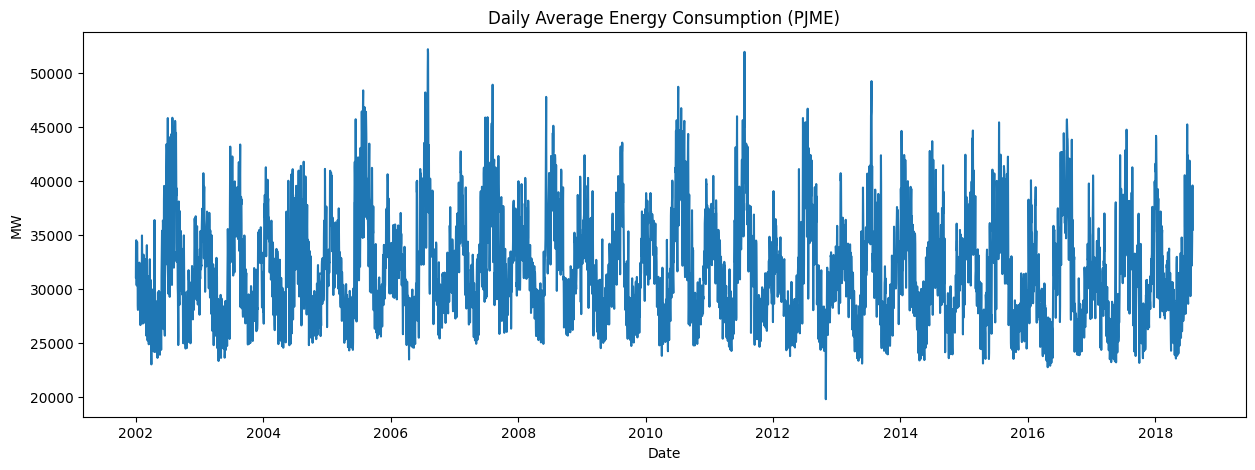

In [7]:
plt.figure(figsize=(15,5))
plt.plot(daily.index, daily['PJME_MW'])
plt.title('Daily Average Energy Consumption (PJME)')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()


Zooming into one year to see the seasonal pattern more clearly.

<Figure size 1500x500 with 0 Axes>

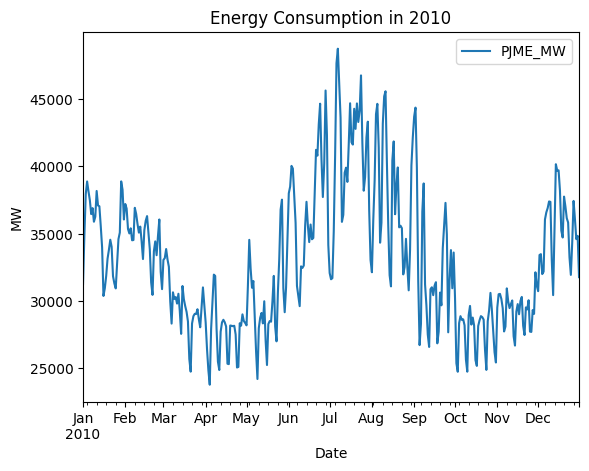

In [23]:
plt.figure(figsize=(15,5))
daily.loc['2010'].plot()
plt.title('Energy Consumption in 2010')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()



## 5. Decompose the Series

This splits the series into trend, seasonality, and residual (noise) parts.

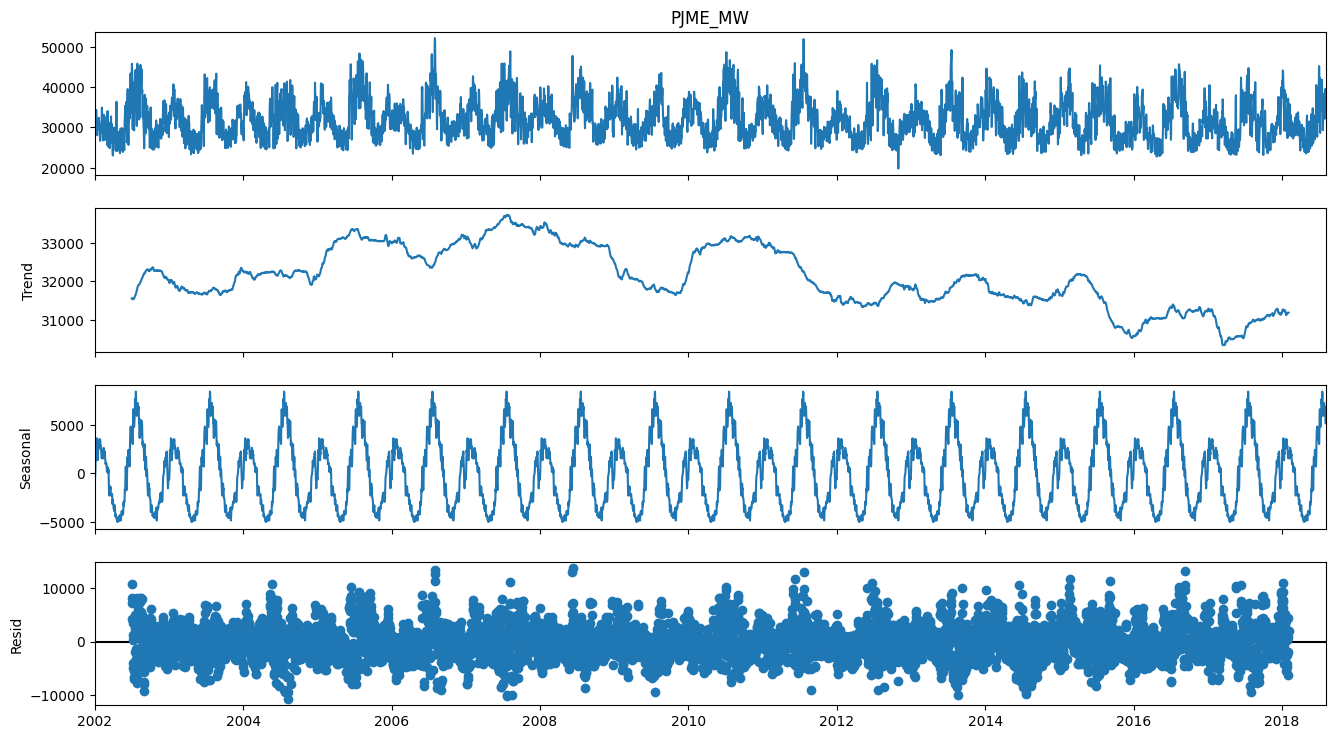

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily['PJME_MW'], model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(15, 8)
plt.show()


## 6. Check if the Data is Stationary

I'm using the Augmented Dickey-Fuller (ADF) test. If the p-value is less than 0.05, the data is considered stationary.

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily['PJME_MW'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] <= 0.05:
    print("The data is stationary")
else:
    print("The data is NOT stationary")


ADF Statistic: -8.262011911890717
p-value: 5.053661719429228e-13
The data is stationary


Even though the ADF test says the data is stationary, there is still clear seasonality
from the plots above (daily/weekly/yearly patterns), so I will still account for that using SARIMA later.

Below are the ACF and PACF plots, which help with picking the ARIMA parameters (p and q).

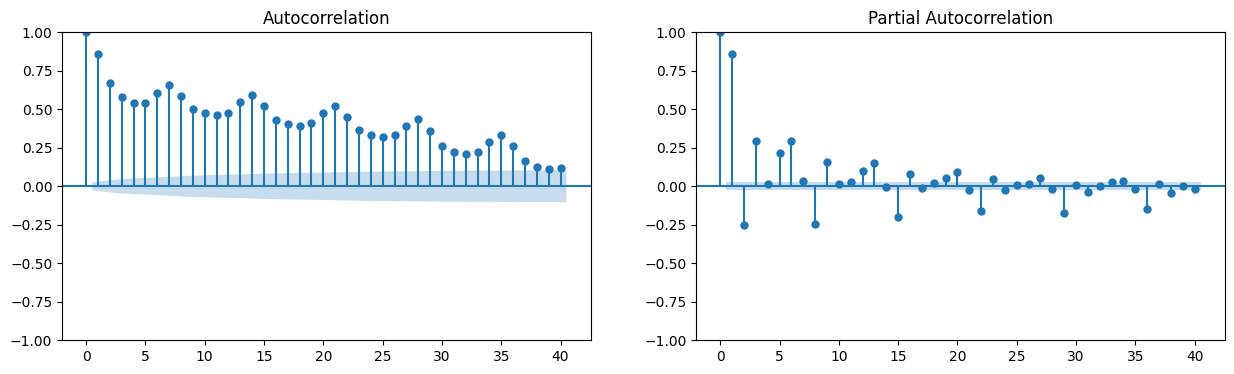

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(daily['PJME_MW'], ax=axes[0], lags=40)
plot_pacf(daily['PJME_MW'], ax=axes[1], lags=40)
plt.show()


## 7. Train / Test Split

Since this is time series data, I can't randomly split it. I'll use the last 90 days as the test set
and everything before that as training data.

In [12]:
train = daily.iloc[:-90]
test = daily.iloc[-90:]

print("Train size:", train.shape)
print("Test size:", test.shape)


Train size: (5969, 1)
Test size: (90, 1)


## 8. Evaluation Function

I'll use this same function to score every model so I can compare them fairly at the end.

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'{name} -> MAE: {mae:.2f}  RMSE: {rmse:.2f}  MAPE: {mape:.2f}%')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []


## 9. Baseline Model - Moving Average

A simple baseline: just use the average of the last 30 days as the forecast for every day in the test set.
Every other model needs to beat this to be worth using.

In [14]:
ma_value = train['PJME_MW'][-30:].mean()
ma_pred = [ma_value] * len(test)

results.append(evaluate(test['PJME_MW'], ma_pred, 'Moving Average'))


Moving Average -> MAE: 5741.52  RMSE: 7356.41  MAPE: 15.91%


## 10. Linear Regression

Here I'm treating forecasting as a regression problem. I made simple features out of the date:
a day counter (to capture trend), day of week, and month (to capture some seasonality).

In [15]:
from sklearn.linear_model import LinearRegression

lr_data = daily.copy()
lr_data['day_num'] = range(len(lr_data))
lr_data['day_of_week'] = lr_data.index.dayofweek
lr_data['month'] = lr_data.index.month

X = lr_data[['day_num', 'day_of_week', 'month']]
y = lr_data['PJME_MW']

X_train, X_test = X.iloc[:-90], X.iloc[-90:]
y_train, y_test = y.iloc[:-90], y.iloc[-90:]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

results.append(evaluate(y_test, lr_pred, 'Linear Regression'))


Linear Regression -> MAE: 4250.21  RMSE: 5180.29  MAPE: 12.62%


## 11. ARIMA

Based on the ACF/PACF plots above, I'm starting with order (2,1,1). Feel free to try other combinations
and see if the score improves.

In [16]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['PJME_MW'], order=(2,1,1))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=90)
results.append(evaluate(test['PJME_MW'], arima_pred, 'ARIMA'))


ARIMA -> MAE: 6077.12  RMSE: 7707.94  MAPE: 16.83%


## 12. SARIMA

ARIMA does not handle seasonality on its own, so this adds a seasonal component.
I'm using a seasonal period of 7 to capture the weekly pattern (weekday vs weekend usage).

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train['PJME_MW'], order=(1,1,1), seasonal_order=(1,1,1,7))
sarima_fit = sarima_model.fit(disp=False)

sarima_pred = sarima_fit.forecast(steps=90)
results.append(evaluate(test['PJME_MW'], sarima_pred, 'SARIMA'))


SARIMA -> MAE: 5652.25  RMSE: 7135.03  MAPE: 15.75%


## 13. Prophet

Prophet is made by Meta and is good at handling trend + multiple seasonalities (daily, weekly, yearly)
automatically, without me having to set the seasonal period manually like with SARIMA.

In [18]:
from prophet import Prophet

prophet_train = train.reset_index().rename(columns={'Datetime': 'ds', 'PJME_MW': 'y'})

prophet_model = Prophet()
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=90)
forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'][-90:].values
results.append(evaluate(test['PJME_MW'], prophet_pred, 'Prophet'))


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet -> MAE: 2608.69  RMSE: 3367.85  MAPE: 7.84%


## 14. Compare All Models

In [19]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE').reset_index(drop=True)
results_df


,Model,MAE,RMSE,MAPE
0,Prophet,2608.694713,3367.851516,7.841207
1,Linear Regression,4250.213663,5180.292150,12.624155
2,SARIMA,5652.250232,7135.032248,15.750110
3,Moving Average,5741.523148,7356.413105,15.908167
4,ARIMA,6077.122616,7707.941048,16.834894


Plotting all the forecasts against the actual test values.

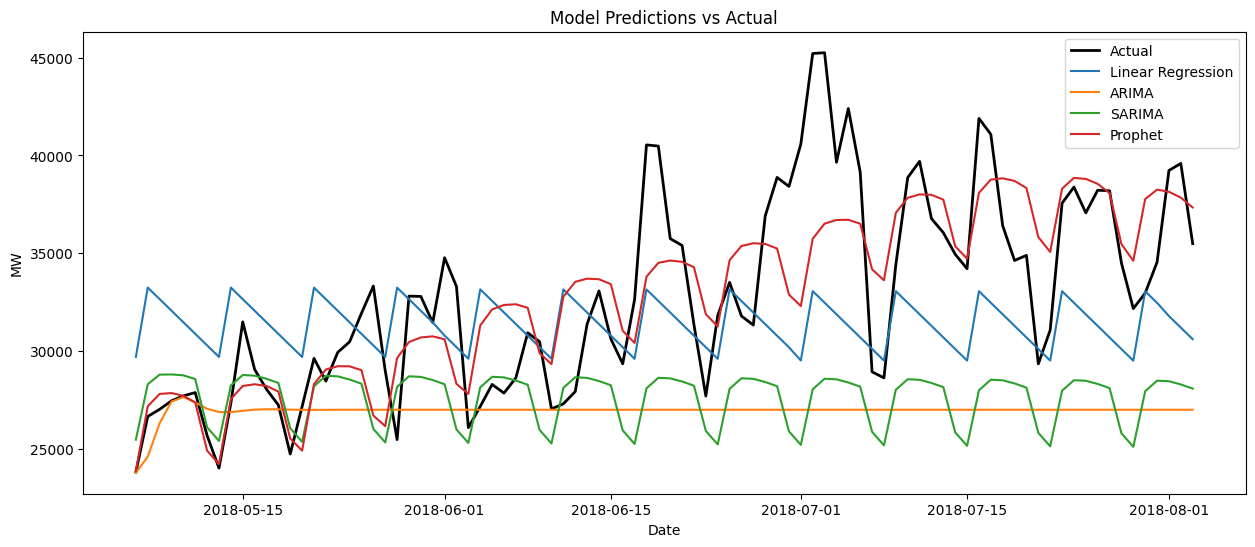

In [20]:
plt.figure(figsize=(15,6))
plt.plot(test.index, test['PJME_MW'], label='Actual', color='black', linewidth=2)
plt.plot(test.index, lr_pred, label='Linear Regression')
plt.plot(test.index, arima_pred, label='ARIMA')
plt.plot(test.index, sarima_pred, label='SARIMA')
plt.plot(test.index, prophet_pred, label='Prophet')
plt.legend()
plt.title('Model Predictions vs Actual')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()


## 15. Conclusion

Based on the comparison table, Prophet performed the best out of all five models, with the lowest error across MAE, RMSE, and MAPE (7.84% MAPE). Looking at the plot, this makes sense — Prophet was the only model that captured both the weekly pattern and the rising trend going into summer at the same time. SARIMA correctly picked up the weekly seasonality but missed the summer trend since it was only set up to look at a 7-day cycle. ARIMA performed the worst, even worse than the moving average baseline, because with no seasonal component its 90-day forecast flattens out toward the average instead of following the trend. Linear Regression landed in the middle, but its sawtooth-shaped predictions show it wasn't really learning a meaningful pattern from the day-of-week feature. Overall, this shows that for data with multiple layers of seasonality (daily, weekly, yearly), a model like Prophet — which handles all of that automatically — works better than models that need the seasonal period manually specified.
